# 03 機械学習 - 相変化の自動検出

**目的**:　　
316パターンの時系列XRDデータに機械学習を適用し、La2Ni3からLaNi2Hxへの相転移を自動検出・定量化。

**おもな内容**:  
- PCA: 4096次元のスペクトルデータを低次元に圧縮（参考文献Sato et al.では目視解析）
- K-means: 相変化は不連続な状態遷移として現れるため、クラスタリングが有効
- 回帰: 温度・圧力からスペクトル特徴量を予測できるかを検証する（相図の定量化を目指した試み。結果は本文で率直に議論する）

## 対象読者・前提知識・動作環境・版とライセンス

**対象読者**:  
ARIMデータポータル会員の研究者・技術者を想定しています。`01_eda.ipynb`・`02_signal_processing.ipynb`で前処理済みのデータを引き継ぎます。主成分分析(PCA)・K-meansクラスタリング・ランダムフォレスト回帰・交差検証は、scikit-learnに初めて触れる方でも理解できるよう都度基礎から説明します。

**シリーズ構成**:  
本ノートブックは「La2Ni3高圧水素化その場観察XRD」4部作の第3部です（第1部: `01_eda.ipynb`、第2部: `02_signal_processing.ipynb`、第4部: `04_data_analysis_summary.ipynb`）。

**動作環境**:  
Python 3.13、pandas・numpy・matplotlib・scipy・scikit-learn 1.7で動作確認しています。日本語フォントは`matplotlib_fontja`パッケージを利用します。

**データの出典・ライセンス**:  
`01_eda.ipynb`と同じくARIMデータポータル公開データセットを使用します。  
DOI：　https://doi.org/10.71947/arim.jpmxp1222qs0007

### 教材への接続
Google Colab環境でこのノートブックを実行する場合は、次のセルを実行してください。（<font color="red">ローカル環境などGoogle Colabを使わない場合は不要です</font>）

In [ ]:
! pip install matplotlib_fontja
! git clone https://github.com/ARIM-Usecase/Claude_Cowork.git
%cd Claude_Cowork

## 0. データセットの読み込みと前処理

### ライブラリのインポート
本コードで扱うpythonのライブラリをimport文でロードします。 

In [ ]:
import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_fontja

from scipy.signal import savgol_filter
from scipy.ndimage import minimum_filter1d

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold
from sklearn.metrics import silhouette_score, r2_score, mean_absolute_error

warnings.filterwarnings("ignore")


### 作業フォルダーの設定
プロジェクトルート:  
Jupyterは通常notebookファイルのあるフォルダをカレントディレクトリとして起動するため、Path.cwd()がそのままプロジェクトルートになります。

In [2]:
BASE_DIR = Path.cwd()
DATA_PROC = BASE_DIR / "data" / "processed"
XRD_SEQ = DATA_PROC / "xrd" / "sequential"
META_DIR = DATA_PROC / "metadata"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

### 定義関数

In [3]:
def energy_to_d(e, two_theta_deg=6.0):
    return 12.398 / (2 * np.sin(np.radians(two_theta_deg/2)) * e)

def baseline_correction(s, window=120):
    bl = minimum_filter1d(s.astype(float), size=window)
    return np.clip(s - bl, 0, None)

### データ読み込み・前処理（01・02と同じ手順: スムージング→ベースライン補正）

In [4]:
# データ読み込み・前処理（01・02と同じ手順: スムージング→ベースライン補正）
df_meta = pd.read_csv(META_DIR / "metadata_table.csv")
df_seq_meta = df_meta[df_meta["filename"].str.startswith("seq")].reset_index(drop=True)
seq_files = sorted([f for f in os.listdir(XRD_SEQ) if f.endswith(".csv")])
n_patterns = len(seq_files)

print(f"Number of patterns: {n_patterns}")

E_MIN, E_MAX = 20.0, 110.0
df0 = pd.read_csv(XRD_SEQ / seq_files[0])
mask_e = (df0["energy"] >= E_MIN) & (df0["energy"] <= E_MAX)
energy_axis = df0["energy"][mask_e].values
d_axis = energy_to_d(energy_axis)
n_ch = len(energy_axis)

#パターンマトリクスの作成
I_matrix = np.zeros((n_patterns, n_ch), dtype=np.float32)

for i, fname in enumerate(seq_files):
    df_xrd = pd.read_csv(XRD_SEQ / fname)
    m = (df_xrd["energy"] >= E_MIN) & (df_xrd["energy"] <= E_MAX)
    I_matrix[i, :] = df_xrd["intensity"][m].values[:n_ch]

#スムージング
I_smooth = savgol_filter(I_matrix, window_length=15, polyorder=3, axis=1)
I_corr = np.zeros_like(I_smooth)

#ベースライン補正
for i in range(n_patterns):
    I_corr[i] = baseline_correction(I_smooth[i])

temps = df_seq_meta["temperature_K"].values[:n_patterns]
pressures = df_seq_meta["pressure_GPa"].values[:n_patterns]

print("Preprocessing complete")

Number of patterns: 316
Preprocessing complete


## 1. 主成分分析 (PCA)

以降のPCA・K-meansは、温度・圧力ラベルを一切使わずスペクトル形状だけから低次元表現・グループ分けを行う**教師なし学習**です。　　

教師なし学習では「訓練データ・テストデータ」という区別自体が存在しないため、全316パターンを使って`fit`することは適切です。　（データリーケージには当たりません。リーケージが問題になるのは、後述するセクション3のように、ラベル（温度）を予測する**教師あり学習**の性能を評価する場面です）。

### PCA: 2090チャンネル → 低次元

《齋藤さんへの質問》　パターンマトリクスの測定ポイント（2090チャネル）をPCAで次元削減します。下記では寄与率をみるために10次元までを取得しています。さて、このようなXRDでの次元削減でPCAの適用は一般的でしょうか。この点について留意点があれば教えてください。

In [5]:
# データの標準化
scaler = StandardScaler()
I_scaled = scaler.fit_transform(I_corr)

# PCAの実行
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(I_scaled)

print("=== PCAにおける寄与率（explained variance ratio） ===")

for i, (ev, cev) in enumerate(zip(pca.explained_variance_ratio_,
                                    np.cumsum(pca.explained_variance_ratio_))):
    print(f"PC{i+1}: {ev*100:.1f}% (cumulative: {cev*100:.1f}%)")

=== PCAにおける寄与率（explained variance ratio） ===
PC1: 25.5% (cumulative: 25.5%)
PC2: 22.8% (cumulative: 48.3%)
PC3: 10.9% (cumulative: 59.2%)
PC4: 7.5% (cumulative: 66.7%)
PC5: 4.6% (cumulative: 71.3%)
PC6: 4.3% (cumulative: 75.6%)
PC7: 3.1% (cumulative: 78.7%)
PC8: 2.5% (cumulative: 81.2%)
PC9: 1.8% (cumulative: 83.0%)
PC10: 1.4% (cumulative: 84.4%)


### PCAスコアプロット（PC1 vs PC2、色=温度・圧力）

《齋藤さんへの質問》  
1. PCAスコアに温度情報、圧力情報でカラーバーを表示したものです。いかがでしょうか。ここから得られる情報はどのようなものがありますでしょうか。とくに反応（相変化）を読み取るポイントは？　　
1. 線形の次元削減の場合にはＰＣ＿１、ＰＣ＿２に意味をもたせることもできます。どのような情報が多く含まれている軸でしょうか。
1. ３つ目の時系列におけるＰＣ１、ＰＣ２はどのような意味があるでしょうか。
1. ＰＣ１、ＰＣ３やＰＣ２ーＰＣ３のような３番目のスコアを表示することもできますが、こちらはいかがでしょうか。



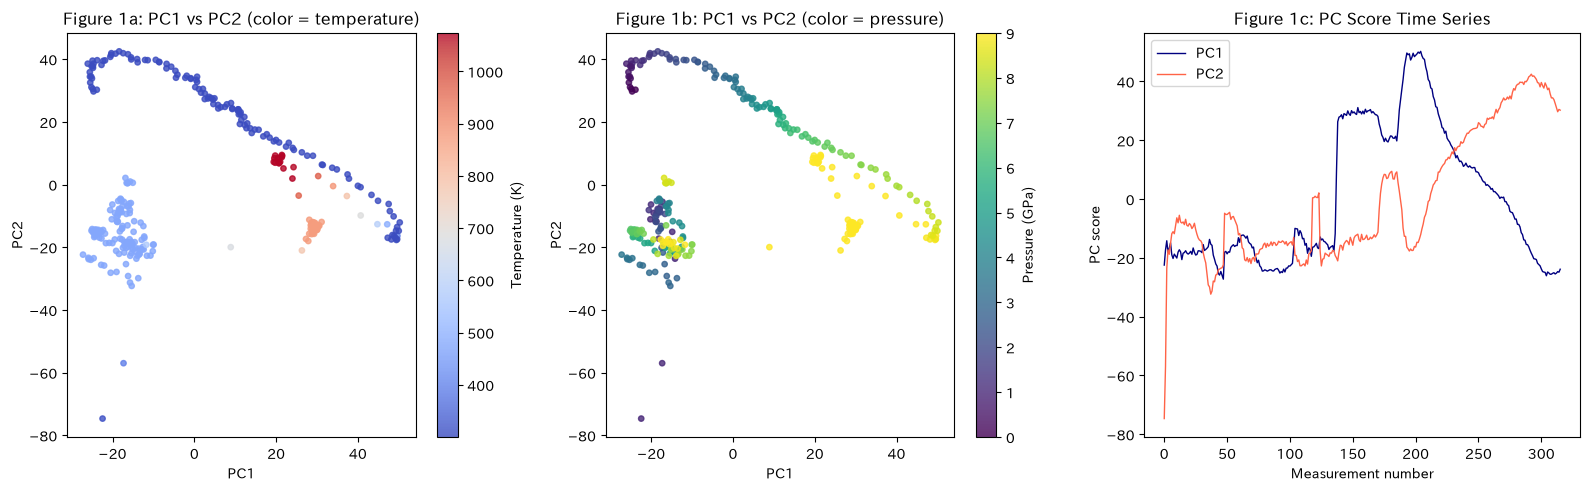

Correlation PC1 vs temperature: 0.304
Correlation PC2 vs temperature: -0.378
Correlation PC1 vs pressure:    0.656
Correlation PC2 vs pressure:    -0.393


In [7]:
# PCAスコアプロット（PC1 vs PC2、色=温度・圧力）
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sc0 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=temps, cmap="coolwarm", s=15, alpha=0.8)
plt.colorbar(sc0, ax=axes[0], label="Temperature (K)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("Figure 1a: PC1 vs PC2 (color = temperature)")

sc1 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=pressures, cmap="viridis", s=15, alpha=0.8)
plt.colorbar(sc1, ax=axes[1], label="Pressure (GPa)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("Figure 1b: PC1 vs PC2 (color = pressure)")

seq_num = np.arange(n_patterns)
axes[2].plot(seq_num, X_pca[:,0], lw=1, color="navy", label="PC1")
axes[2].plot(seq_num, X_pca[:,1], lw=1, color="tomato", label="PC2")
axes[2].set_xlabel("Measurement number"); axes[2].set_ylabel("PC score")
axes[2].set_title("Figure 1c: PC Score Time Series")
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig01_pca_scores.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Correlation PC1 vs temperature: {np.corrcoef(X_pca[:,0], temps)[0,1]:.3f}")
print(f"Correlation PC2 vs temperature: {np.corrcoef(X_pca[:,1], temps)[0,1]:.3f}")
print(f"Correlation PC1 vs pressure:    {np.corrcoef(X_pca[:,0], pressures)[0,1]:.3f}")
print(f"Correlation PC2 vs pressure:    {np.corrcoef(X_pca[:,1], pressures)[0,1]:.3f}")

### PC1, PC2 の荷重（loadings）= どのd値が主成分に寄与するか  
《齋藤さんへの質問》
1. ローディングを可視化した場合に得られる情報はいかがでしょうか。（とくにガス吸着などの結晶変化をみる場合における着眼点は？）

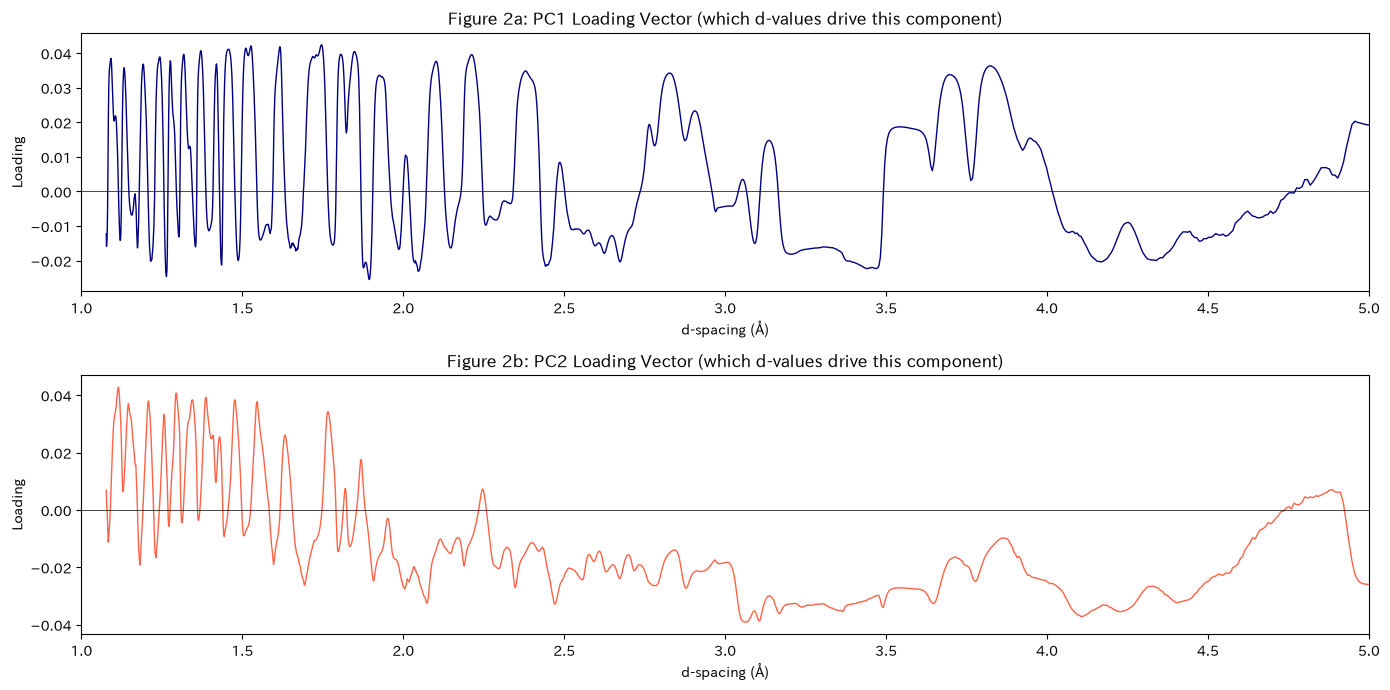

In [8]:
# PC1, PC2 の荷重（loadings）= どのd値が主成分に寄与するか
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for i in range(2):
    axes[i].plot(d_axis, pca.components_[i], lw=1, color=["navy","tomato"][i])
    axes[i].axhline(0, color="black", lw=0.5)
    axes[i].set_xlabel("d-spacing (Å)")
    axes[i].set_ylabel("Loading")
    axes[i].set_title(f"Figure 2{'ab'[i]}: PC{i+1} Loading Vector (which d-values drive this component)")
    axes[i].set_xlim(1, 5)
    
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig02_pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. K-meansクラスタリング（相の自動同定）

### 最適クラスタ数の決定（シルエット係数）  
《齋藤さんへの質問》
1. 相変化の判定において、ここではK-means法を適用する提案がありました。ＰＣＡ上位５成分についてという中で行っていますが、いかがでしょうか。
1. このクラスタ数の決定にはエルボー法などもありますが、ここではシルエット係数法をつかっています。いかがでしょうか。
1. 別のクラスタリングの方法などがあればご教示ください。

In [6]:
# 最適クラスタ数の決定（シルエット係数）
X_for_km = X_pca[:, :5]  # 上位5成分使用
sil_scores = []

k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_for_km)
    sil = silhouette_score(X_for_km, labels)
    sil_scores.append(sil)
    
    print(f"k={k}: silhouette score={sil:.3f}")

best_k = k_range[np.argmax(sil_scores)]

print(f"\nBest number of clusters (by silhouette score): k={best_k}")

k=2: silhouette score=0.372
k=3: silhouette score=0.475
k=4: silhouette score=0.514
k=5: silhouette score=0.476
k=6: silhouette score=0.484
k=7: silhouette score=0.491

Best number of clusters (by silhouette score): k=4


### 最適kでクラスタリング
《齋藤さんへの質問》
1. 今回は４つのクラスタと判定された結果を４つの視点で可視化しています。いかがでしょうか。


In [10]:
# 最適kでクラスタリング
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_best.fit_predict(X_for_km)

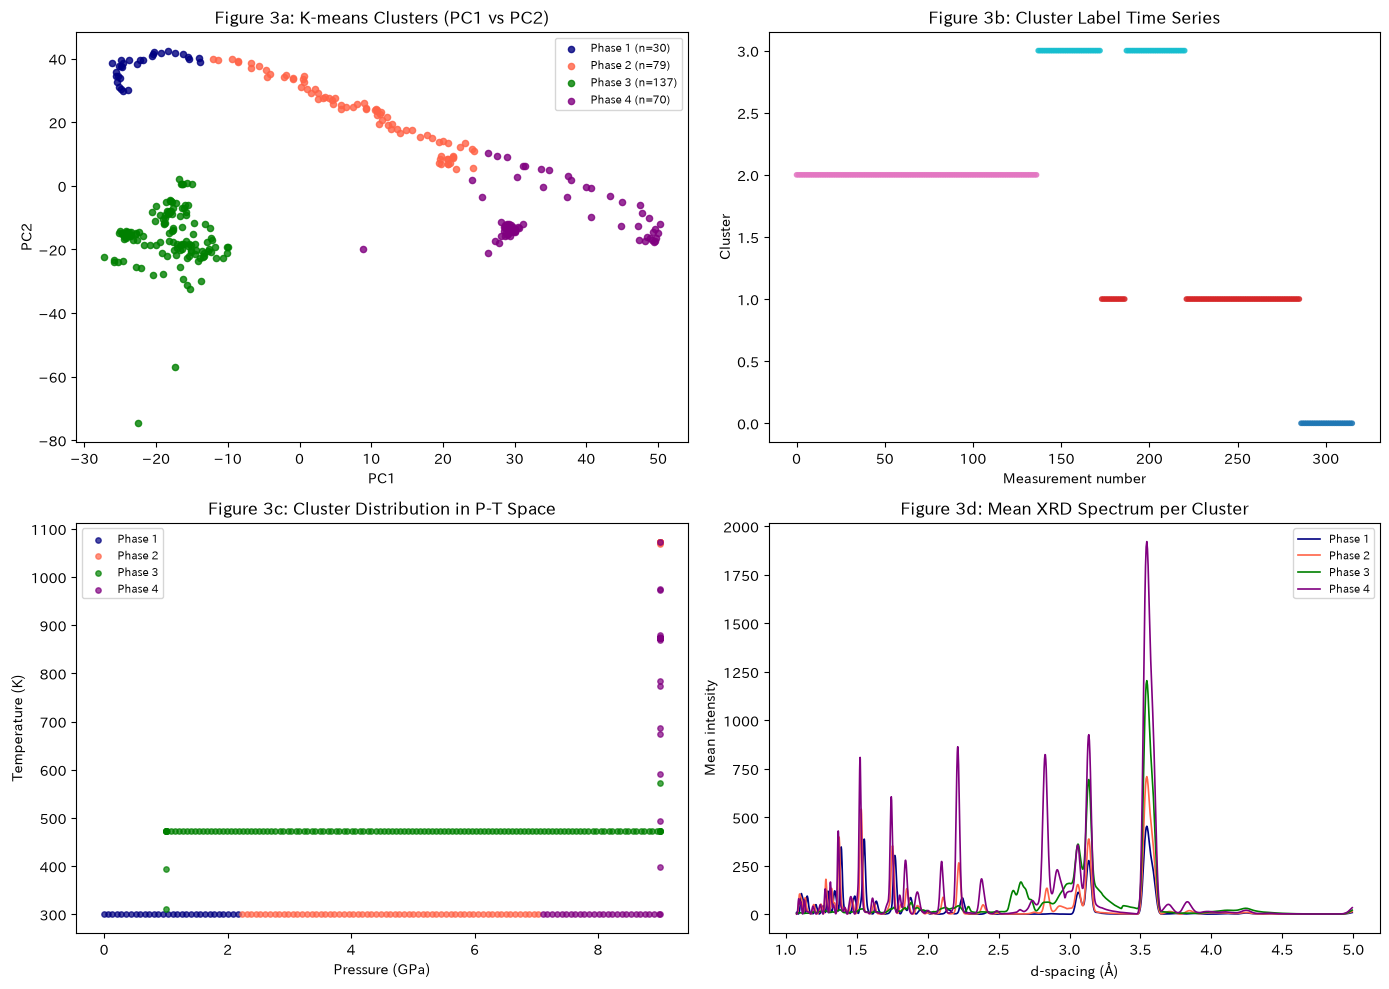

Phase 1: n=30, T mean=300.1K (range 300.1-300.1K), P mean=1.07 GPa
Phase 2: n=79, T mean=437.1K (range 300.1-1073.6K), P mean=5.41 GPa
Phase 3: n=137, T mean=472.1K (range 311.5-571.8K), P mean=4.93 GPa
Phase 4: n=70, T mean=633.5K (range 300.1-1072.6K), P mean=8.65 GPa


In [11]:
# クラスタリング結果の可視化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_cluster = ["navy", "tomato", "green", "purple", "orange", "brown"]

# PC1-PC2プロット
for c in range(best_k):
    mask = cluster_labels == c
    axes[0,0].scatter(X_pca[mask,0], X_pca[mask,1], s=20, alpha=0.8,
                      label=f"Phase {c+1} (n={mask.sum()})", color=colors_cluster[c])
axes[0,0].set_xlabel("PC1"); axes[0,0].set_ylabel("PC2")
axes[0,0].set_title("Figure 3a: K-means Clusters (PC1 vs PC2)")
axes[0,0].legend(fontsize=8)

# 時系列クラスタラベル
axes[0,1].scatter(np.arange(n_patterns), cluster_labels,
                   c=cluster_labels, cmap="tab10", s=10, alpha=0.8)
axes[0,1].set_xlabel("Measurement number"); axes[0,1].set_ylabel("Cluster")
axes[0,1].set_title("Figure 3b: Cluster Label Time Series")

# P-T空間でのクラスタ分布
for c in range(best_k):
    mask = cluster_labels == c
    axes[1,0].scatter(pressures[mask], temps[mask], s=15, alpha=0.7,
                      label=f"Phase {c+1}", color=colors_cluster[c])
axes[1,0].set_xlabel("Pressure (GPa)"); axes[1,0].set_ylabel("Temperature (K)")
axes[1,0].set_title("Figure 3c: Cluster Distribution in P-T Space")
axes[1,0].legend(fontsize=8)

# 各クラスタの平均スペクトル
for c in range(best_k):
    mask = cluster_labels == c
    mean_spec = I_corr[mask].mean(axis=0)
    d_mask = (d_axis >= 1.0) & (d_axis <= 5.0)
    axes[1,1].plot(d_axis[d_mask], mean_spec[d_mask],
                   label=f"Phase {c+1}", color=colors_cluster[c], lw=1.2)
axes[1,1].set_xlabel("d-spacing (Å)"); axes[1,1].set_ylabel("Mean intensity")
axes[1,1].set_title("Figure 3d: Mean XRD Spectrum per Cluster")
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig03_kmeans_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

for c in range(best_k):
    mask = cluster_labels == c
    print(f"Phase {c+1}: n={mask.sum()}, T mean={temps[mask].mean():.1f}K "
          f"(range {temps[mask].min():.1f}-{temps[mask].max():.1f}K), "
          f"P mean={pressures[mask].mean():.2f} GPa")

## 3. ランダムフォレストによる温度回帰（スペクトル→温度予測）

ここからは「XRDスペクトルの形状から温度を予測できるか」という**教師あり回帰**を扱います。教師あり学習の性能評価では、テストに使うデータの情報が訓練側に一切混ざらないようにする必要があります。前処理（標準化・PCA）とモデル（RandomForest）を`Pipeline`にまとめ、交差検証（cross-validation, CV）の**各フォールド内で**標準化・PCAをfitすることで、この原則を守ります。

《齋藤様》　物質判定のようなことは少ないと思いますので、このような回帰型のスペクトル同定のニーズは少ないかと思いますが、どうでしょうか。


In [12]:
# 標準化・PCA・RandomForestを1つのPipelineにまとめる。
# こうすることで、交差検証の各フォールドにおいて、標準化とPCAが
# そのフォールドの訓練データだけでfitされ、テストフォールドの情報が
# 混入しない（データリーケージを防ぐ）

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5, random_state=42)),
    ("rf", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
])

X_all = I_corr  # 生のスペクトル特徴量(2090チャンネル)をそのままPipelineに渡す
y_temp = temps

# cv=5（整数）を渡すと、scikit-learnは既定でKFold(shuffle=False)を使う。
# つまり測定順のまま5つの連続したブロックに分割される。時系列で測定された
# このデータでは、これは「これまで見た温度域から、まだ見ていない温度域を
# 予測できるか」を試す、素直で厳しい評価になる

cv_scores_block = cross_val_score(pipe, X_all, y_temp, cv=5, scoring="neg_mean_absolute_error")
y_pred_block = cross_val_predict(pipe, X_all, y_temp, cv=5)
mae_block = -cv_scores_block.mean()
r2_block = r2_score(y_temp, y_pred_block)


print("(1) 5-fold CV, measurement-order blocks (honest, no leakage):")
print(f"    MAE per fold: {np.round(-cv_scores_block, 1)}")
print(f"    Mean MAE: {mae_block:.1f} K,  R2: {r2_block:.3f}")

(1) 5-fold CV, measurement-order blocks (honest, no leakage):
    MAE per fold: [ 72.2   9.6 514.2 316.2 277.1]
    Mean MAE: 237.9 K,  R2: -1.512


In [13]:
# (1)の結果はかなり悪い(R2が負＝平均値で予測するより悪い)かもしれません。
# なぜでしょうか。比較のため、(2)ランダムにシャッフルした分割 と
# (3)訓練データそのものに対する当てはめ、も見てみます

cv_shuffled = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_shuf = cross_val_score(pipe, X_all, y_temp, cv=cv_shuffled, scoring="neg_mean_absolute_error")
y_pred_shuf = cross_val_predict(pipe, X_all, y_temp, cv=cv_shuffled)

print("(2) 5-fold CV, shuffled (adjacent, near-duplicate frames can leak between folds):")
print(f"    Mean MAE: {-cv_scores_shuf.mean():.1f} K,  R2: {r2_score(y_temp, y_pred_shuf):.3f}")

pipe.fit(X_all, y_temp)
y_pred_insample = pipe.predict(X_all)

print("(3) In-sample fit (train == test, no held-out data at all):")
print(f"    MAE: {mean_absolute_error(y_temp, y_pred_insample):.1f} K,  "
      f"R2: {r2_score(y_temp, y_pred_insample):.3f}")

# 診断: 各ブロックで、テストフォールドの温度範囲は訓練フォールドの範囲に収まっているか
print("\nDiagnosis - temperature range per fold (measurement-order blocks):")
kf_diag = KFold(n_splits=5, shuffle=False)
for i, (tr, te) in enumerate(kf_diag.split(y_temp)):
    covered = y_temp[te].min() >= y_temp[tr].min() and y_temp[te].max() <= y_temp[tr].max()
    print(f"  fold {i}: test T {y_temp[te].min():.0f}-{y_temp[te].max():.0f}K, "
          f"train T {y_temp[tr].min():.0f}-{y_temp[tr].max():.0f}K, "
          f"test range within train range? {covered}")

(2) 5-fold CV, shuffled (adjacent, near-duplicate frames can leak between folds):
    Mean MAE: 12.6 K,  R2: 0.973
(3) In-sample fit (train == test, no held-out data at all):
    MAE: 4.1 K,  R2: 0.997

Diagnosis - temperature range per fold (measurement-order blocks):
  fold 0: test T 311-473K, train T 300-1074K, test range within train range? True
  fold 1: test T 473-473K, train T 300-1074K, test range within train range? True
  fold 2: test T 473-1074K, train T 300-686K, test range within train range? False
  fold 3: test T 300-686K, train T 300-1074K, test range within train range? True
  fold 4: test T 300-300K, train T 300-1074K, test range within train range? True


### なぜ評価方法によって結果がこれほど異なるのか

上の3つの結果は、同じモデル・同じデータに対する評価なのに、大きく異なります。それぞれ何を測っているのかを整理します。

- **(3) 訓練データへの当てはめ**は、モデルが訓練データそのものをどれだけ覚え込めたかを示すだけで、未知データへの汎化性能とは無関係です。RandomForestは訓練データに対しては非常に高い精度を示しますが、これは「良いモデル」の証拠にはなりません。
- **(2) シャッフルした分割**は一見良好な結果に見えますが、この実験は約60秒おきに連続測定された時系列データです。時間的に隣接するパターンは温度・組成がほぼ同じ、つまりスペクトルもほぼ同じです。シャッフルすると、テストフォールドのパターンとほぼ同一な「お手本」が訓練フォールド側に混ざってしまい、見かけの精度が過大評価されます。
- **(1) 測定順のブロック分割**が、最も誠実な評価です。上のセルの診断結果が示すように、少なくとも1つのフォールドでは、テストフォールドの温度範囲が訓練フォールドの範囲を超えています（決定木ベースのRandomForestは、訓練データで見た目的変数の範囲を超えて外挿することが原理的にできません）。加えて、La2Ni3の水素化反応は不可逆な構造変化であるため、実験の前半と後半とで同じ温度でも試料の結晶構造（＝XRDスペクトル）が異なっている可能性があります。この場合「スペクトル→温度」は単純な1対1の関係にならず、時間的に離れたブロックへの汎化はそもそも原理的に困難です。

**結論**: 本データセットでは、スペクトル形状から温度を精度良く予測する回帰モデルを構築することは、少なくともこの特徴量・モデル・評価設計では成功しませんでした。これは失敗ではなく、「時系列・非可逆な物理過程を、素朴な教師あり回帰で扱うことの限界」を示す重要な結果です。次のセルでは、参考として特徴量重要度（訓練データ全体でfitしたモデルによる）を示しますが、これは予測性能を保証するものではない点に注意してください。

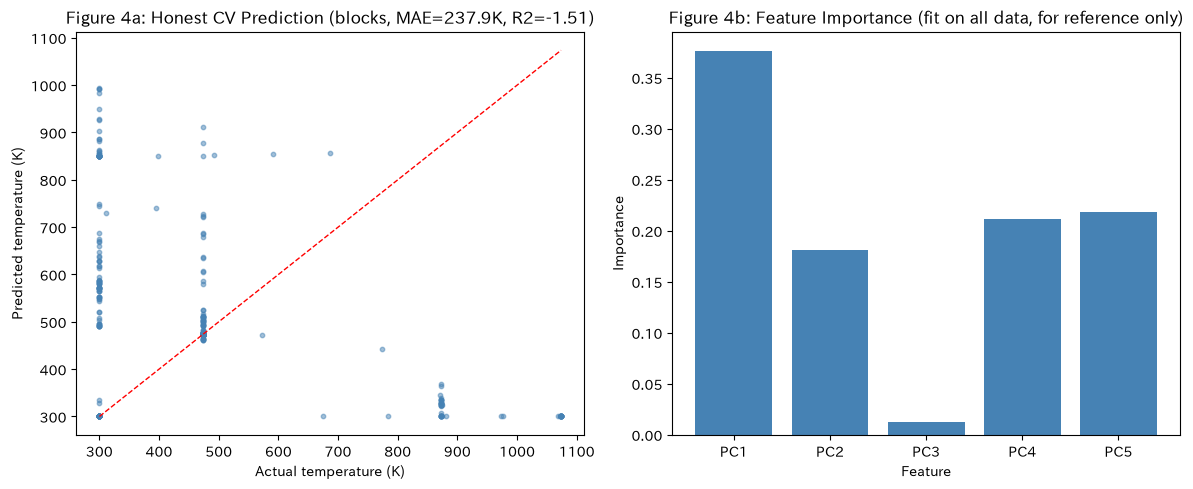

03_machine_learning notebook complete


In [14]:
# 特徴量重要度（訓練データ全体でfitしたモデルより。上の議論の通り、
# 予測精度自体は限定的であることに注意。ここでは「モデルがどのPCに着目したか」
# の参考情報として示す）

feat_names = [f"PC{i+1}" for i in range(5)]
importances = pipe.named_steps["rf"].feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_temp, y_pred_block, s=10, alpha=0.5, color="steelblue")
axes[0].plot([y_temp.min(), y_temp.max()], [y_temp.min(), y_temp.max()], "r--", lw=1)
axes[0].set_xlabel("Actual temperature (K)"); axes[0].set_ylabel("Predicted temperature (K)")
axes[0].set_title(f"Figure 4a: Honest CV Prediction (blocks, MAE={mae_block:.1f}K, R2={r2_block:.2f})")

axes[1].bar(feat_names, importances, color="steelblue")
axes[1].set_xlabel("Feature"); axes[1].set_ylabel("Importance")
axes[1].set_title("Figure 4b: Feature Importance (fit on all data, for reference only)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig04_ml_regression.png", dpi=150, bbox_inches="tight")
plt.show()
print("03_machine_learning notebook complete")

## 4. まとめ・今後の課題・演習問題

### 手法の比較表（温度回帰の評価方法による違い）

| 評価方法 | 何を測っているか | リーケージ・過大評価のリスク |
| --- | --- | --- |
| 訓練データへの当てはめ | モデルの記憶力（汎化性能ではない） | 非常に高い（テスト無し） |
| シャッフルした5-fold CV | 見かけの汎化性能 | 高い（時間的に隣接する類似フレームが漏れる） |
| 測定順ブロックの5-fold CV | 未知の温度域への汎化性能（最も厳しい・誠実な評価） | 低い（ただし外挿が原理的に困難な場合がある） |

具体的な数値（MAE・R2）は、上のセルの実行結果を参照してください（乱数・ライブラリバージョンにより多少変動しうるため、本文には固定値を記載していません）。

### まとめ

- PCAにより2090チャンネルのスペクトルを10次元に圧縮し、上位2主成分だけで元データの分散の過半（具体的な寄与率は実行結果を参照）を説明できることを確認した。
- PCAスコアと温度・圧力の相関を実際に計算したところ、PC1・PC2のどちらが温度、どちらが圧力に対応するかは事前の想定ほど単純ではないことが分かった（相関係数は実行結果を参照）。「主成分の意味」を印象だけで決めつけず、実際に相関を計算して確認することの重要性を示す一例。
- K-meansクラスタリング（シルエット係数で最適kを選択）により、スペクトル形状に基づく複数のフェーズ（相）を教師なしで検出できた。
- ランダムフォレストによる「スペクトル→温度」回帰は、評価方法（訓練データへの当てはめ／シャッフルCV／測定順ブロックCV）によって結果が大きく異なることを実際に確認した。最も誠実な評価（測定順ブロックCV）では、性能は限定的だった。これは、時系列・非可逆な物理過程を素朴な教師あり回帰で扱うことの限界を示す重要な発見である。

### 本ノートブックで扱っていないこと（今後の課題）

- PDindexer等による系統的なピークインデックス・相同定（→引き続き今後の課題）
- なぜPC1・PC2が温度・圧力と単純に対応しないのかの詳細な物理的解釈
- 反応の不可逆性を明示的にモデル化する手法（例: 経過時間や反応進行度を特徴量に加える）
- 圧力・温度それぞれを個別に予測するのではなく、両者を同時に扱うモデル

### 演習問題

1. `X_for_km = X_pca[:, :5]`を`X_pca[:, :2]`（PC1・PC2のみ）に変更すると、シルエット係数と最適クラスタ数`best_k`はどう変わりますか。
2. セクション3の`pipe`の`PCA(n_components=5)`を`n_components=2`や`n_components=20`に変えると、測定順ブロックCVのMAE・R2はどう変化しますか。
3. `KFold(n_splits=5, shuffle=False)`を`n_splits=10`に変更し、フォールドごとの温度範囲（診断セル）を確認してください。フォールド数を増やすと外挿の問題は緩和されますか、悪化しますか。
4. `RandomForestRegressor`を`sklearn.linear_model.Ridge`など別の回帰モデルに置き換えて、同じ3種類の評価（訓練当てはめ／シャッフルCV／ブロックCV）を比較してください。木ベースモデル特有の「範囲外への外挿ができない」という弱点は、線形モデルでも同様に現れますか。